In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import os

import mlrose_hiive
from mlrose_hiive import QueensGenerator, MaxKColorGenerator, TSPGenerator
# from mlrose_hiive import SARunner, GARunner, NNGSRunner, RHCRunner, MIMICRunner
from mlrose_hiive import QueensGenerator
from mlrose_hiive import RHCRunner

from utils import get_run_group_dfs_rhc

In [2]:
EXPERIMENT_NAME = 'RHC_Queens_GridSearch'
SEED = 0
PROBLEM_SIZE_LIST = [8]
ITERATIONS_LIST = [1e9]
MAX_ATTEMPTS_LIST = [50]
RESTART_LIST = [100]
NUM_RUNS = 5

In [ ]:
output_dir = f'metrics/{EXPERIMENT_NAME}'
os.makedirs(output_dir, exist_ok=True)

In [3]:
all_df = pd.DataFrame()
group_i = 0
run_i = 0
for problem_size in PROBLEM_SIZE_LIST:
    for iterations in ITERATIONS_LIST:
        for max_attempts in tqdm(MAX_ATTEMPTS_LIST):
            for restarts in RESTART_LIST:
                for i in range(NUM_RUNS):
                    problem = QueensGenerator().generate(seed=SEED+i, size=8)
                    sa = RHCRunner(
                        problem=problem,
                        experiment_name='dontcare',
                        output_directory='~/temp',
                        seed=SEED+i,
                        max_attempts=max_attempts,
                        iteration_list=[iterations],
                        restart_list = [restarts],
                    )
                    _, df_run_curves = sa.run()
                    df_run_curves['group_number'] = group_i
                    df_run_curves['run_number'] = run_i
                    df_run_curves['problem_size'] = problem_size
                    df_run_curves['max_iterations'] = iterations
                    df_run_curves['max_attempts'] = max_attempts
                    df_run_curves['max_restarts'] = restarts
                    all_df = pd.concat([all_df, df_run_curves], axis=0)
                    run_i += 1
                group_i += 1
all_df.reset_index(inplace=True, drop=True)

100%|██████████| 1/1 [00:01<00:00,  1.59s/it]


In [4]:
all_df['Fitness'] = -1 * all_df['Fitness']

In [5]:
all_df.to_csv(os.path.join(output_dir, 'learning_curve.csv'), index=False)

In [6]:
# df = pd.read_csv('temp.csv')

In [7]:
len(all_df['run_number'].unique())

5

In [8]:
all_df['Fitness'].max()

-0.0

In [9]:
run_df, group_df = get_run_group_dfs_rhc(all_df)

In [10]:
group_df

,group_number,problem_size,max_iterations,max_attempts,max_restarts,total_iterations_mean,total_iterations_std,total_time_mean,total_time_std,best_fitness_mean,best_fitness_std,total_fevals_mean,total_fevals_std,total_restarts_mean,total_restarts_std
0,0,16,1.000000e+09,50,100,119.4,30.04663,0.014809,0.005422,0.0,0.0,977.4,1060.077733,10.0,12.103718


In [11]:
max_fit = group_df['best_fitness_mean'].max()
best_df = group_df[group_df['best_fitness_mean'] == max_fit]
len(best_df)

1

<Axes: >

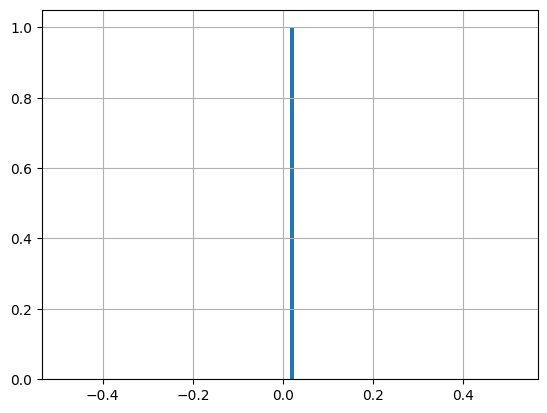

In [12]:
best_df['total_time_mean'].hist(bins=100)

<Axes: >

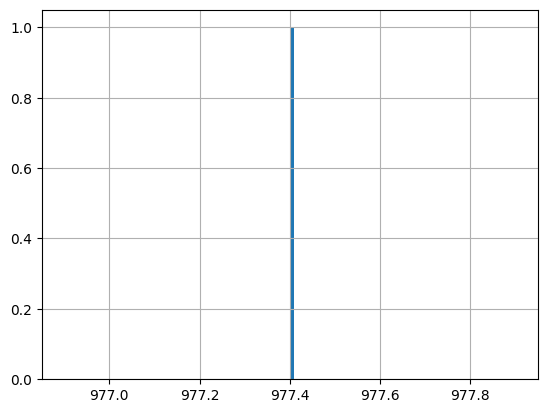

In [13]:
best_df['total_fevals_mean'].hist(bins=100)

In [14]:
min_time = best_df['total_time_mean'].min()
min_fevals = best_df['total_fevals_mean'].min()
min_time, min_fevals

(0.014808991800000015, 977.4)

In [15]:
best_df[best_df['total_time_mean'] == min_time]['total_fevals_mean']

0    977.4
Name: total_fevals_mean, dtype: float64

In [16]:
import matplotlib.pyplot as plt

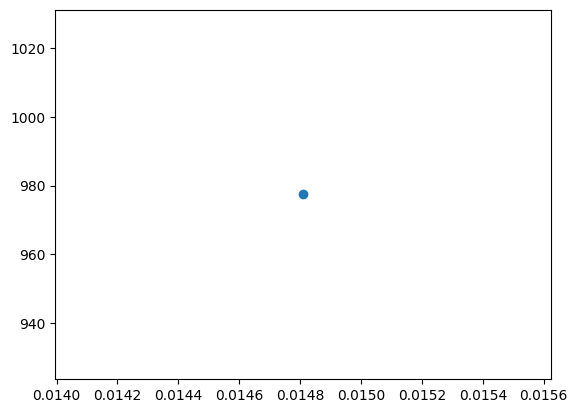

In [17]:
plt.plot(best_df['total_time_mean'], best_df['total_fevals_mean'], 'o')

In [18]:
best_df[best_df['total_time_mean'] == min_time]

,group_number,problem_size,max_iterations,max_attempts,max_restarts,total_iterations_mean,total_iterations_std,total_time_mean,total_time_std,best_fitness_mean,best_fitness_std,total_fevals_mean,total_fevals_std,total_restarts_mean,total_restarts_std
0,0,16,1.000000e+09,50,100,119.4,30.04663,0.014809,0.005422,0.0,0.0,977.4,1060.077733,10.0,12.103718


In [19]:
# problem_size	max_iterations	max_attempts	max_restarts	total_iterations_mean	total_iterations_std	total_time_mean	total_time_std	best_fitness_mean	best_fitness_std	total_fevals_mean	total_fevals_std	total_restarts_mean	total_restarts_std
# 8	            1.000000e+09	50	            100	            139.0	                0.0	                    0.015603	    0.000175	    0.0	                0.0	                1501.0	            0.0	                15.0	            0.0